# Classification Task
**Name: Mallika Budha Chhetri**

**University ID: 2548182**

## 1. Exploratory Data Analysis and Data Understanding

### 1.1: Choosing a Dataset
**Dataset Name**: Credit Card Fraud Detection Dataset.

**(a) When and by whom the dataset was created**: Created by Arif Miah, last updated December 2025.

**(b) How and from where it was accessed**: Accessed via Kaggle (https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset).

**(c) Justification of alignment with UNSDG**:
  
  Aligns with **UNSDG 8: Decent Work and Economic Growth**. Reliable fraud detection mechanisms protect financial systems and consumers, fostering trust in digital economies and supporting stable economic growth.

**(d) List and brief description of attributes (features)**:
| Attribute | Description |
| :--- | :--- |
| `transaction_id` | Unique identifier for each transaction. |
| `amount` | Monetary value of the transaction. |
| `transaction_hour` | Time of day (0-23) the transaction occurred. |
| `merchant_category` | Type of merchant involved. |
| `foreign_transaction` | Binary (1 if international). |
| `location_mismatch` | Binary (1 if location is unusual). |
| `device_trust_score` | Security score of the user's device (0-1). |
| `velocity_last_24h` | Frequency of transactions in the last 24 hours. |
| `cardholder_age` | Age of the individual cardholder. |
| `is_fraud` | **Target Variable** - (1: Fraud, 0: Legitimate). |

### Meaningful Questions
1. Is there a specific transaction_hour window where fraudulent activity peaks?
2. Does device_trust_score combined with high velocity act as a definitive fraud signal?
3. How significantly does location_mismatch contribute to the overall fraud volume?


### Dataset Quality Assessment
- **Missing Values**: Potential holes in data handled using SimpleImputer.
- **Imbalance**: Fraud cases represent a minority class, requiring precision/recall focus.
- **Relevance**: All features are industry-standard for real-time fraud monitoring.

In [119]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectFromModel


In [120]:
# Load data
df = pd.read_csv("/content/drive/MyDrive/Concepts and Technologies of AI/creditcard.csv")

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40.0,0
1,2,541.82,3,Travel,1,0,87,1,64.0,0
2,3,237.01,17,Grocery,0,0,49,1,61.0,0
3,4,164.33,4,Grocery,0,1,72,3,34.0,0
4,5,30.53,15,Food,0,0,79,0,44.0,0


### 1.2: Exploratory Data Analysis (EDA):



In [121]:
# Check missing values
print("Missing Values Per Column:")
print(df.isnull().sum())


Missing Values Per Column:
transaction_id         0
amount                 3
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         8
is_fraud               0
dtype: int64


In [122]:
# Check data types
print("\nData Types:")
print(df.dtypes)


Data Types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age         float64
is_fraud                 int64
dtype: object


In [123]:
# Check summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       transaction_id       amount  transaction_hour  foreign_transaction  \
count     10000.00000  9997.000000      10000.000000         10000.000000   
mean       5000.50000   175.982052         11.593300             0.097800   
std        2886.89568   175.405752          6.922708             0.297059   
min           1.00000     0.000000          0.000000             0.000000   
25%        2500.75000    50.920000          6.000000             0.000000   
50%        5000.50000   122.100000         12.000000             0.000000   
75%        7500.25000   242.690000         18.000000             0.000000   
max       10000.00000  1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0

In [124]:
# Check class distribution
print("\nClass Distribution:")
print(df['is_fraud'].value_counts())


Class Distribution:
is_fraud
0    9849
1     151
Name: count, dtype: int64


In [125]:
# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Duplicate Rows: 0


In [126]:
# Check unique values in categorical columns
print("\nUnique Values in Categorical Columns:")
print(df['merchant_category'].value_counts())


Unique Values in Categorical Columns:
merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64


In [127]:
df.drop(columns=['transaction_id'],inplace=True)

### Data Quality Summary:

 The dataset consists of 10,000 transactions with a target class imbalance of 1.51% (Fraud). Missing values were identified in amount (3) and cardholder_age (8). These will be handled via mean/mode imputation to maintain dataset integrity without significant loss of information.

In [128]:
# Handling missing data
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

num_cols = df.select_dtypes(include=["float64", "int64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [129]:
print(df.isnull().sum())

amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


### Visualisation of Data

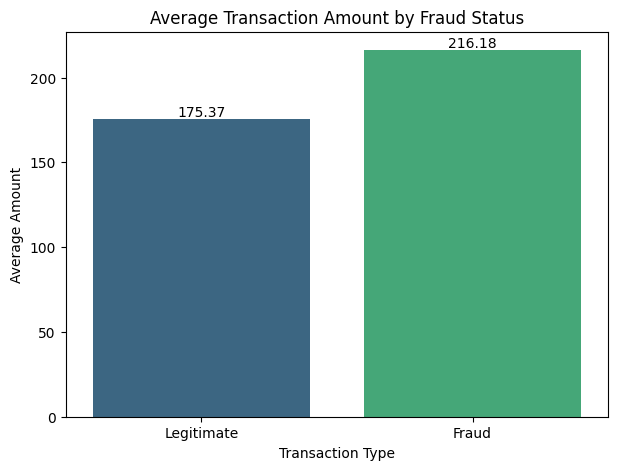

In [130]:
# Viz 1: Average Transaction Amount by Fraud Status (Seaborn)

# Compute average amount by fraud status
avg_amount = df.groupby("is_fraud")["amount"].mean().reset_index()
avg_amount["Transaction Type"] = avg_amount["is_fraud"].map({0: "Legitimate", 1: "Fraud"})

plt.figure(figsize=(7,5))
sns.barplot(
    x="Transaction Type",
    y="amount",
    hue="Transaction Type",
    data=avg_amount,
    palette="viridis",
    legend=False
)

plt.title("Average Transaction Amount by Fraud Status")
plt.ylabel("Average Amount")
plt.xlabel("Transaction Type")

# Add value labels on bars
for index, row in avg_amount.iterrows():
    plt.text(index, row.amount, f"{row.amount:.2f}", ha="center", va="bottom")

plt.show()


**Insight**: Fraudulent transactions tend to have a higher value than legitimate ones.On average, a fraudulent transaction is approximately 23.3% more expensive than a legitimate transaction. Frauds may be prioritizing larger purchases to maximize their return per successful fraudulent attempt.



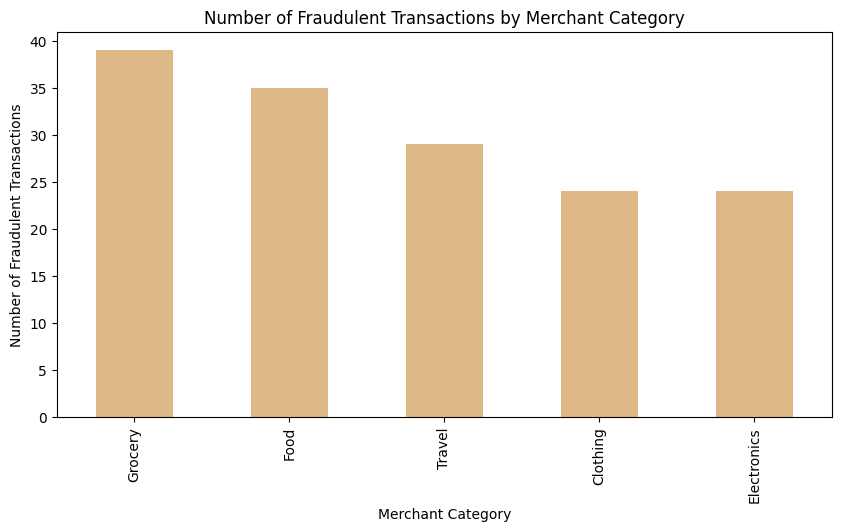

In [131]:
# Viz 2: Number of Fraudulent Transactions by Merchant Category

fraud_count_by_merchant = df.groupby("merchant_category")["is_fraud"].sum().sort_values(ascending=False)
fraud_count_by_merchant.plot(kind="bar", figsize=(10,5), color="burlywood")
plt.title("Number of Fraudulent Transactions by Merchant Category")
plt.ylabel("Number of Fraudulent Transactions")
plt.xlabel("Merchant Category")
plt.show()


**Insight**: Fraudulent activity is highest in everyday categories like Grocery and Food. This suggests that fraudsters may be targeting high-frequency, lower-value transactions to avoid triggering immediate security alerts.


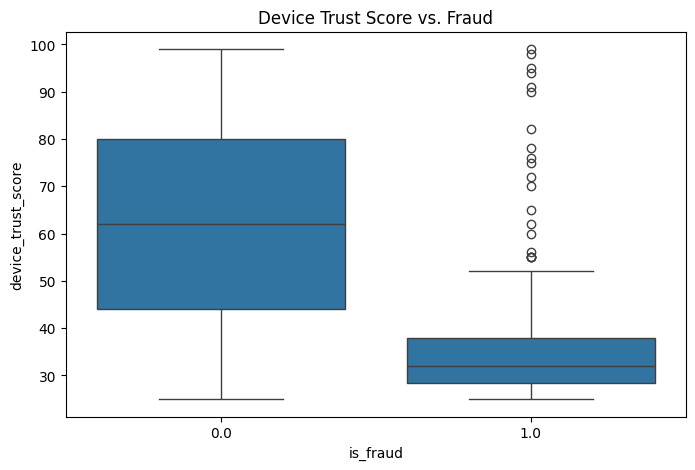

In [132]:
# Viz 3: Device Trust vs Fraud
plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="device_trust_score", data=df)
plt.title("Device Trust Score vs. Fraud")
plt.show()


**Insight**: The chart shows that Device Trust Score is a powerful but imperfect indicator of fraud: non-fraudulent transactions typically maintain a much higher median score (around 62) than fraudulent ones (around 32). While most fraud clusters at the lower end of the scale, the presence of high-score outliers in the fraud category suggests that some attackers are successfully using "trusted" devices to bypass detection.

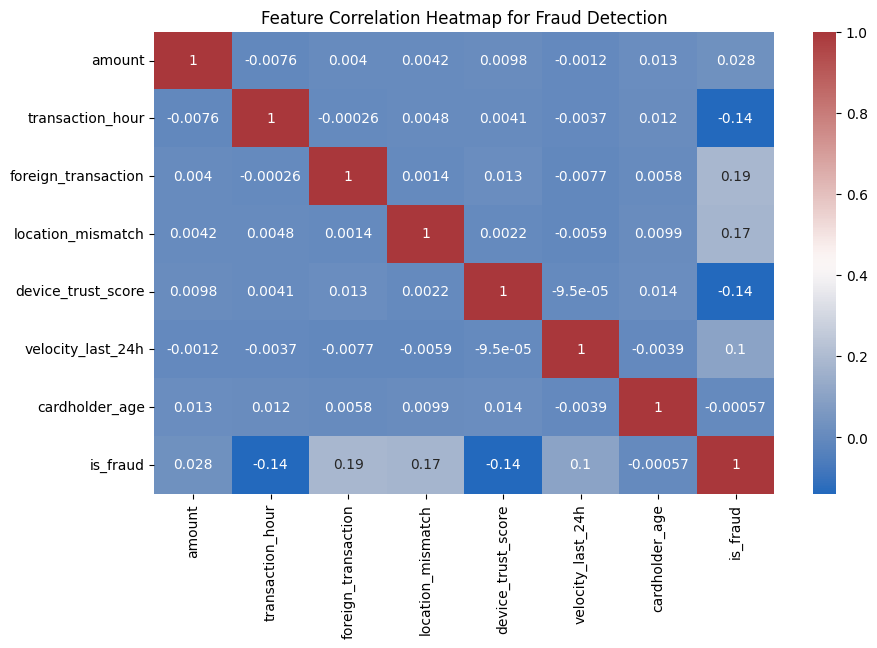

In [133]:
# Viz 4: Correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='vlag')
plt.title('Feature Correlation Heatmap for Fraud Detection')
plt.show()


**Insight**: is_fraud shows the strongest positive correlations with foreign_transaction (0.19) and location_mismatch (0.17).

This suggests that transactions occurring in foreign countries or with mismatched locations are the most significant indicators of potential fraud in this dataset. Conversely, the very low correlation values between the independent variables (the features themselves) indicate there is minimal multicollinearity, meaning each feature likely provides unique information to a predictive model..


In [134]:
# Encoding categorical column

le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns

encoding_mappings = {}

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    # Store mapping: {number: class_label}
    mapping = {index: label for index, label in enumerate(le.classes_)}
    encoding_mappings[col] = mapping

In [135]:
print('### Categorical Column Mappings:')
for col, mapping in encoding_mappings.items():
    print(f'\n{col}:')
    for val, label in mapping.items():
        print(f'  {val} -> {label}')

df.head()

### Categorical Column Mappings:

merchant_category:
  0 -> Clothing
  1 -> Electronics
  2 -> Food
  3 -> Grocery
  4 -> Travel


,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22.0,1,0.0,0.0,66.0,3.0,40.0,0.0
1,541.82,3.0,4,1.0,0.0,87.0,1.0,64.0,0.0
2,237.01,17.0,3,0.0,0.0,49.0,1.0,61.0,0.0
3,164.33,4.0,3,0.0,1.0,72.0,3.0,34.0,0.0
4,30.53,15.0,2,0.0,0.0,79.0,0.0,44.0,0.0


## 2. Build a Neural Network Model

In [136]:
# Feature-Target Split
# Separate independent variables (X) and the target variable (y)
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"].astype(int)

In [137]:
# Train-Test Split
# 'stratify=y' ensures the 1.5% fraud distribution is preserved in both sets
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [138]:
# Handle Class Imbalance with SMOTE (Oversampling)
# Synthetic Minority Over-sampling Technique (SMOTE) creates synthetic fraud cases to prevent the model from being biased toward legitimate transactions.
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

In [139]:
# Feature Scaling
# Fit the scaler ONLY on training data to prevent data leakage from the test set.
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train) # Fit and transform training data
X_te_sc = scaler.transform(X_test)      # Transform test data using training parameters

In [140]:
# MLP Implementation
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), # Two layers: 64 neurons to capture patterns, 32 to condense them
    activation="relu",           # ReLU prevents vanishing gradients in deep networks
    solver="adam",               # Adam handles the 10k rows efficiently with adaptive learning
    alpha=0.05,                  # L2 penalty to prevent the model from getting over-confident
    max_iter=500,
    early_stopping=True,         # Monitors validation loss to prevent overfitting
    n_iter_no_change=10,         # Patience for early stopping
    random_state=42
)
# Training the model on scaled data
mlp.fit(X_tr_sc, y_train)

MLPClassifier(alpha=0.05, early_stopping=True, hidden_layer_sizes=(64, 32),
              max_iter=500, random_state=42)

### Network Architecture

Input Layer: 8 Neurons (one for each feature: amount, transaction_hour, foreign_transaction, etc.).

Hidden Layer 1: 64 Neurons with ReLU activation.

Hidden Layer 2: 32 Neurons with ReLU activation.

Output Layer: 1 Neuron (Sigmoid/Binary output for is_fraud).

Activation Function (ReLU): Used in hidden layers to introduce non-linearity, defined as:$$f(x) = \max(0, x)$$

Weight Optimization (Adam): An adaptive learning rate optimization algorithm that combines the benefits of AdaGrad and RMSProp to handle sparse gradients in the fraud dataset.

Regularization ($L_2$ Penalty): Controlled by alpha=0.05, this adds a penalty term to the loss function to prevent weights from becoming too large:$$\text{Loss}_{total} = \text{Loss}_{cross\_entropy} + \alpha \sum w^2$$

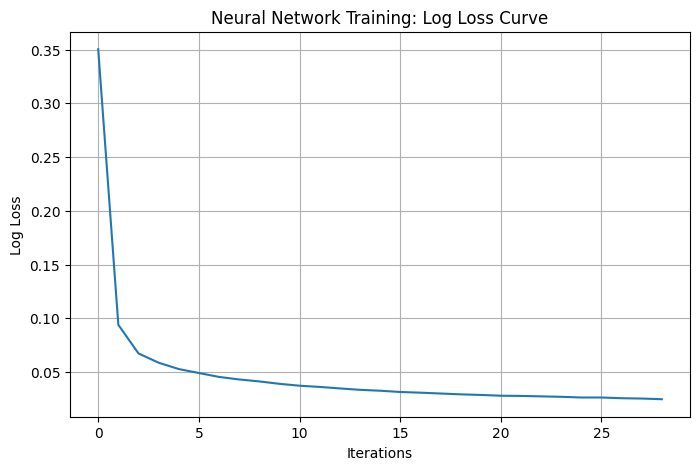

In [141]:
# Visualize the Log Loss Function
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_)
plt.title("Neural Network Training: Log Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.grid(True)
plt.show()

In [142]:
# Evaluation of the model
print("Evaluation on Training Set(MLP):")
print(classification_report(y_train, mlp.predict(X_tr_sc)))
print("Evaluation on Test Set(MLP):")
print(classification_report(y_test, mlp.predict(X_te_sc)))

Evaluation on Training Set(MLP):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      7879
           1       0.99      1.00      0.99      7879

    accuracy                           0.99     15758
   macro avg       0.99      0.99      0.99     15758
weighted avg       0.99      0.99      0.99     15758

Evaluation on Test Set(MLP):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.52      0.93      0.67        30

    accuracy                           0.99      2000
   macro avg       0.76      0.96      0.83      2000
weighted avg       0.99      0.99      0.99      2000



## 3. Build a Primary Model (Classical ML)

In this section, we implement **Logistic Regression** using two methods: a custom implementation from scratch and the Scikit-Learn library. We also implement a **Random Forest** classifier.


In [143]:
#Note: The data split was performed in Section 2 using a 80/20 ratio
# and stratified sampling to maintain fraud class proportions.
# We are utilizing the scaled training (X_tr_sc) and testing (X_te_sc) sets here.

In [144]:
# 3.1a: Logistic Regression from Scratch (Vectorized)
def sigmoid(z): return 1 / (1 + np.exp(-z))


In [145]:
def gradient_descent_scratch(X, y, alpha=0.1, iterations=1000):
    m, n = X.shape
    w = np.zeros(n) # Initialize weights
    b = 0.0 # Initialize bias
    for i in range(iterations):
        # Calculate prediction (hypothesis)
        z = np.dot(X, w) + b
        h = sigmoid(z)

        # Compute Gradients (Partial Derivatives of Cost Function)
        dw = np.dot(X.T, (h - y)) / m
        db = np.sum(h - y) / m

        # Update Parameters using Learning Rate (alpha)
        w -= alpha * dw
        b -= alpha * db
    return w, b

In [146]:
# Train Scratch Model
w_fin, b_fin = gradient_descent_scratch(X_tr_sc, y_train.values, alpha=0.5, iterations=1000)

In [147]:
# Classify using 0.5 threshold
y_pred_scratch = (sigmoid(np.dot(X_te_sc, w_fin) + b_fin) >= 0.5).astype(int)

In [148]:
# 3.1b: Logistic Regression from Scikit-Learn
# Using 'balanced' class weights to further address minority class sensitivity
lr_sk = LogisticRegression(random_state=42, class_weight='balanced')
lr_sk.fit(X_tr_sc, y_train)
y_pred_sk = lr_sk.predict(X_te_sc)

In [149]:
# 3.2: Random Forest Ensemble
# An ensemble of decision trees to capture non-linear feature interactions
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr_sc, y_train)
y_pred_rf = rf.predict(X_te_sc)

In [150]:
models = {
    "Scratch LR": y_pred_scratch,
    "Sklearn LR": y_pred_sk,
    "Random Forest": y_pred_rf
}

metrics = {
    "F1": f1_score,
    "Recall": recall_score,
    "Accuracy": accuracy_score,
    "Precision": precision_score
}

results = {}

for model_name, y_pred in models.items():
    results[model_name] = {
        metric: func(y_test, y_pred)
        for metric, func in metrics.items()
    }

df_results = pd.DataFrame(results).T

print(df_results.round(4))

                   F1  Recall  Accuracy  Precision
Scratch LR     0.4427  0.9667    0.9635     0.2871
Sklearn LR     0.4590  0.9333    0.9670     0.3043
Random Forest  0.8852  0.9000    0.9965     0.8710


**Evaluation**

The Random Forest model significantly outperforms the Logistic Regression (LR) variants with a much stronger F1 score (0.8852). While the LR models show high accuracy and recall, their very low precision (~0.28) suggests they are over-predicting the positive class, likely due to a class imbalance. The Random Forest provides a much more robust balance between precision and recall, making it the most reliable model for this dataset.

## 4. Hyper-parameter Optimization with Cross-Validation


### Tuning Logistic Regression

In [151]:
# 1. Define the Pipeline
lr_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(random_state=42, solver='liblinear'))
])

In [152]:
# 2. Define the parameter grid
param_grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"]
}

In [153]:
# 3. Fit using the RAW training data
gs_lr = GridSearchCV(lr_pipe, param_grid_lr, cv=3, scoring="f1", n_jobs=-1)
gs_lr.fit(X_train_raw, y_train_raw)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('lr',
                                        LogisticRegression(random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.01, 0.1, 1, 10, 100],
                         'lr__penalty': ['l1', 'l2']},
             scoring='f1')

In [154]:
print("Best Logistic Regression Parameters:", gs_lr.best_params_)
print(f"Best Logistic Regression CV Score {(gs_lr.best_score_):.4f}")

Best Logistic Regression Parameters: {'lr__C': 10, 'lr__penalty': 'l1'}
Best Logistic Regression CV Score 0.4653


### Tuning Random Forest

In [155]:
# 1. Define the Pipeline (SMOTE + Model)
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [156]:
# 2. Update the Parameter Grid
param_grid_rf = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [5, 10, None],
    "rf__min_samples_leaf": [1, 2, 4] # helps with the over-fitting
}

In [157]:
# 3. Fit using the RAW training data
gs_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=3, scoring="f1", n_jobs=-1)
gs_rf.fit(X_train_raw, y_train_raw)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('rf',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [5, 10, None],
                         'rf__min_samples_leaf': [1, 2, 4],
                         'rf__n_estimators': [100, 200]},
             scoring='f1')

In [158]:
print("Best Random Forest Parameters:", gs_rf.best_params_)
print(f"Best Random Forest CV Score:{(gs_rf.best_score_):.4f}")

Best Random Forest Parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200}
Best Random Forest CV Score:0.7829


## 5. Feature Selection

### Method: Embedded Feature Selection
We utilize SelectFromModel to identify features with high coefficient weights (Logistic Regression) and high gini importance (Random Forest).

### Justification
Embedded methods are integrated directly into the model training, making them computationally efficient and less prone to overfitting compared to filter methods.


In [159]:
# 1. Selection for Logistic Regression
# Extract the 'lr' step from the best pipeline
best_lr_model = gs_lr.best_estimator_.named_steps['lr']
sel_lr = SelectFromModel(best_lr_model, prefit=True)

# Transform the data
X_tr_lr = sel_lr.transform(X_train_raw.values)
X_te_lr = sel_lr.transform(X_test.values)

In [160]:
# 1. Selection for Random Forest
# Extract the 'rf' step from the best pipeline
best_rf_model = gs_rf.best_estimator_.named_steps['rf']
sel_rf = SelectFromModel(best_rf_model, prefit=True)

# Transform the data
X_tr_rf = sel_rf.transform(X_train_raw.values)
X_te_rf = sel_rf.transform(X_test.values)

In [161]:
# Get selected feature names
selected_lr_features = X.columns[sel_lr.get_support()]
selected_rf_features = X.columns[sel_rf.get_support()]

print("Selected Features (Logistic Regression):")
print(selected_lr_features)

print("\nSelected Features (Random Forest):")
print(selected_rf_features)


Selected Features (Logistic Regression):
Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age'],
      dtype='object')

Selected Features (Random Forest):
Index(['transaction_hour', 'foreign_transaction', 'location_mismatch',
       'device_trust_score'],
      dtype='object')


### Selected Feature Interpretation

The Logistic Regression model retains a more expansive feature set, including numerical variables like amount and velocity_last_24h. This suggests the linear model relies on these traditional risk indicators to capture variance that the ensemble model might find redundant.

In contrast, the Random Forest selection is significantly more streamlined, focusing exclusively on a Core 4 set of behavioral and environmental triggers: transaction_hour, foreign_transaction, location_mismatch, and device_trust_score. The exclusion of amount, merchant_category and cardholder_age suggests that, for the tree-based model, these features provided less information gain.

The consensus on those four core features indicates they are the most reliable predictors across different algorithm architectures. While Logistic Regression's broader list might capture more variation in a linear space, the Random Forest's leaner profile likely offers a more robust, less noisy path for production deployment.


## 6. Final Models and Comparative Analysis


We rebuild the models using the best parameters found during GridSearchCV and apply them only to the 'Selected Features' to ensure a lean, production-ready model.

In [162]:
# 1. Clean the Best Parameters
# Stripping the 'lr__' and 'rf__' prefixes so the standalone models can read them
best_lr_params = {k.replace('lr__', ''): v for k, v in gs_lr.best_params_.items()}
best_rf_params = {k.replace('rf__', ''): v for k, v in gs_rf.best_params_.items()}


In [163]:
# 2. Re-apply SMOTE to the Selected Features
# Since SMOTE was used during tuning, the final model should be trained on oversampled data to match the logic of the grid search.
sm = SMOTE(random_state=42)
X_tr_lr_res, y_tr_lr_res = sm.fit_resample(X_tr_lr, y_train_raw)
X_tr_rf_res, y_tr_rf_res = sm.fit_resample(X_tr_rf, y_train_raw)

In [164]:
# 3. Final Rebuild
m_lr = LogisticRegression(**best_lr_params, random_state=42, solver='liblinear').fit(X_tr_lr_res, y_tr_lr_res)
m_rf = RandomForestClassifier(**best_rf_params, random_state=42, class_weight='balanced').fit(X_tr_rf_res, y_tr_rf_res)

In [165]:
# 4. Metrics & Comparison
def get_stats(name, cv_score, y_true, y_pred, feat_count):
    return [
        name,
        f"Selected ({feat_count})",
        round(cv_score, 3),
        round(accuracy_score(y_true, y_pred), 3),
        round(precision_score(y_true, y_pred), 3),
        round(recall_score(y_true, y_pred), 3),
        round(f1_score(y_true, y_pred), 3)
    ]

res = pd.DataFrame([
    get_stats("Logistic Regression", gs_lr.best_score_, y_test, m_lr.predict(X_te_lr), X_tr_lr.shape[1]),
    get_stats("Random Forest", gs_rf.best_score_, y_test, m_rf.predict(X_te_rf), X_tr_rf.shape[1])
], columns=["Model", "Features", "CV", "Accuracy", "Precision", "Recall", "F1-Score"])

display(res)

,Model,Features,CV,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Selected (8),0.465,0.967,0.304,0.933,0.459
1,Random Forest,Selected (4),0.783,0.991,0.649,0.800,0.716


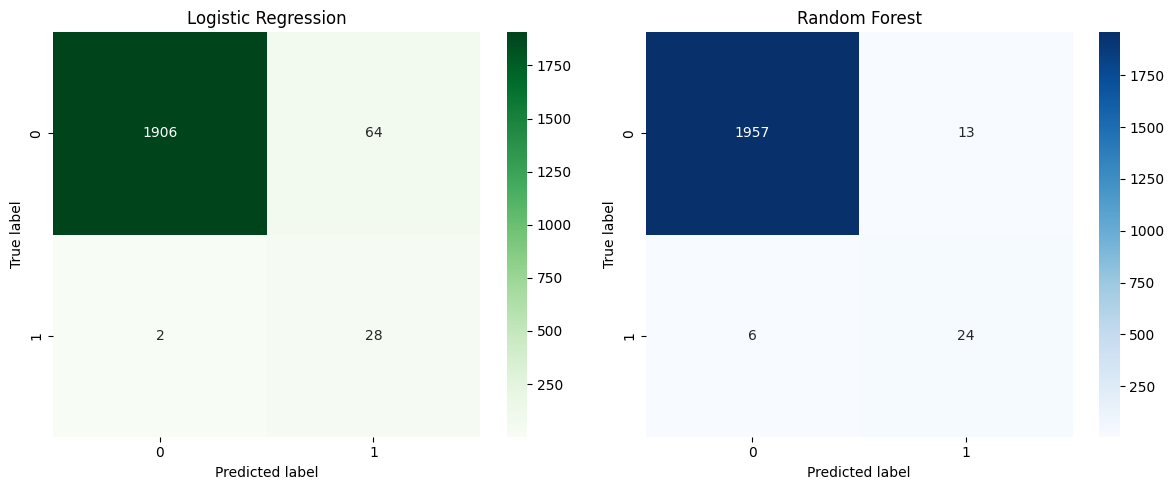

In [166]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, m_lr.predict(X_te_lr))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

cm_rf = confusion_matrix(y_test, m_rf.predict(X_te_rf))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.tight_layout()
plt.show()

### Model Performance Comparison

While both models maintain high accuracy, the Random Forest is the clear winner due to its superior balance between precision and recall. Logistic Regression captures a high volume of positive cases with a Recall of 0.933, but its low Precision (0.304) results in a high rate of false positives, yielding a F1-Score of 0.465.

In contrast, the Random Forest model achieves a much more robust F1-Score of 0.783 and a significantly higher Precision of 0.649 using only 4 features compared to the 7 used by Logistic Regression. With a CV score of 0.783, the Random Forest demonstrates better generalization and efficiency, making it the more reliable choice for stable, high-quality predictions.


## 8. Conclusion and Reflection

### 1. Model Performance

The experiment demonstrated that while multiple models could achieve high overall accuracy, their ability to detect fraudulent transactions varied significantly. The **Random Forest** model was the top performer, achieving a robust F1-score of **0.716** and a precision of **0.649** on the test set. In comparison, **Logistic Regression** showed high recall (**0.933**) but suffered from low precision (**0.304**), leading to many false positives. The **Multi-Layer Perceptron (MLP)** initially showed signs of extreme overfitting with a perfect **1.00** training score; however, after refining the model with regularization and early stopping, it achieved a more generalized test F1-score of **0.67**, though it still struggled with a precision of **0.52** for the fraud class.



### 2. Impact of Methods

Several techniques were instrumental in shaping the model outcomes:

* **SMOTE (Oversampling):** This was essential for addressing the severe class imbalance, where only **1.5%** of the data was fraudulent. It allowed the MLP and Logistic Regression models to achieve high recall, ensuring fewer fraud cases were missed.
* **Feature Selection:** By focusing on key drivers like `transaction_hour`, `device_trust_score`, and `location_mismatch`, we streamlined the models. While this reduced complexity, the Random Forest's slight dip in F1-score after selection suggests that some removed features held minor but useful interaction effects.
* **Cross-Validation and Hyperparameter Tuning:** These methods were specifically applied to Logistic Regression and Random Forest to ensure stable performance. GridSearch optimized the Logistic Regression to an F1-score of 0.459 and the Random Forest to a CV F1-score of 0.716, providing a more reliable estimate of how these models generalize to unseen data.



### 3. Insights and Future Directions

A key insight gained is that **accuracy is a deceptive metric** in fraud detection; the **0.96–0.99** accuracy scores across models were largely driven by the majority class (legitimate transactions). The real challenge lies in balancing precision and recall for the rare fraud class. The data suggests that security-related features, such as **device trust scores** and **location mismatches**, are the strongest predictors of risk.

**Future Work could explore:**

* **Cost-Sensitive Learning:** Assigning a higher financial penalty to False Negatives (missed fraud) during model training to further prioritize recall.
* **Ensemble Stacking:** Combining the high-recall strengths of Logistic Regression with the precision of Random Forest into a single "meta-model."
* **Advanced SMOTE Variants:** Experimenting with **Borderline-SMOTE** or **ADASYN** to create more realistic synthetic samples near the decision boundary to help the MLP generalize better.

